# 07 - Modelos Preentrenados con Hugging Face

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Asignatura Ministerial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de este laboratorio es explorar y utilizar modelos preentrenados de última generación en visión por computadora a través del ecosistema oficial de Hugging Face. Analizaremos cómo transferir el conocimiento de modelos robustos ya entrenados en enormes conjuntos de datos para resolver tareas de clasificación general, clasificación zero-shot flexible y detección espacial de múltiples objetos en imágenes cotidianas.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Cargar y utilizar pipelines de inferencia de Hugging Face de manera ágil y eficiente.
2. Clasificar imágenes complejas utilizando la arquitectura Vision Transformer (ViT).
3. Aplicar clasificación zero-shot con CLIP para evaluar categorías personalizadas mediante lenguaje natural.
4. Detectar y localizar de forma espacial múltiples objetos de forma de simultánea utilizando DETR.
5. Comparar las ventajas de velocidad, flexibilidad y precisión espacial entre diferentes modelos de visión.

## Terminología clave (Microglosario)

*   **Modelos Preentrenados:** Redes neuronales ya optimizadas en gigantescos conjuntos de datos por laboratorios de investigación, listas para ser usadas directamente o adaptadas.
*   **Transformers en Visión (ViT):** Arquitectura que adapta los mecanismos de autoatención (atención a patches de imágenes) en lugar de utilizar convoluciones tradicionales.
*   **Clasificación Zero-Shot:** Capacidad de una red de clasificar muestras en categorías personalizadas que el modelo no ha visto explícitamente durante un entrenamiento específico. El modelo compara la imagen con el significado de cada texto y asigna una puntuación de similitud. Es zero-shot porque no necesita ejemplos adicionales ni reentrenamiento, y es flexible porque las categorías pueden modificarse en el momento.  En modelos de Hugging Face como CLIP, esto es posible porque imágenes y textos se representan en un espacio común. Es útil para experimentar rápidamente con categorías nuevas, aunque sus puntuaciones expresan similitud, no una certeza absoluta.
*   **Detección de Objetos:** Tarea de localizar espacialmente múltiples elementos en una escena indicando su etiqueta categórica y coordenadas exactas (bounding boxes).
*   **Pipeline de Inferencia:** Abstracción simplificada que encapsula la carga del modelo, preprocesamiento de entradas e interpretación de salidas en pocas instrucciones de código.

## 1. Configuración del Entorno de Ejecución

Procederemos con la instalación silenciosa de las librerías necesarias del ecosistema PyTorch y Hugging Face para trabajar con los pesos y arquitecturas oficiales.

In [12]:
%pip install timm

  Using cached timm-1.0.27-py3-none-any.whl.metadata (40 kB)
Using cached timm-1.0.27-py3-none-any.whl (2.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Verificamos las dependencias del kernel sin instalar ni modificar paquetes.
print('✓ Kernel especializado: Python 3.12 (PyTorch - Hugging Face Vision)')
from importlib.metadata import version
for paquete in ('torch', 'torchvision', 'transformers', 'opencv-python', 'matplotlib', 'requests', 'pillow'):
    print(f'{paquete}: {version(paquete)}')
print('✓ Dependencias verificadas correctamente.')

✓ Kernel especializado: Python 3.12 (PyTorch - Hugging Face Vision)
torch: 2.12.1
torchvision: 0.27.1
transformers: 5.12.1
opencv-python: 4.13.0.92
matplotlib: 3.11.0
requests: 2.34.2
pillow: 12.2.0
✓ Dependencias verificadas correctamente.


In [2]:
# Este bloque importa las herramientas necesarias para descargar imágenes desde internet,
# ejecutar modelos preentrenados de HuggingFace y visualizar los resultados con anotaciones.
import torch
from transformers import pipeline  # API de alto nivel de HuggingFace: permite usar modelos preentrenados con una sola línea de código.
from PIL import Image, ImageDraw, ImageFont  # Image para cargar; ImageDraw e ImageFont para dibujar cajas y etiquetas sobre los resultados.
import requests
from io import BytesIO  # Permite tratar los bytes de una respuesta HTTP como un archivo, sin necesidad de guardarlo en disco.
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

print('✓ Librerías esenciales importadas correctamente.')
print(f'  • Versión de PyTorch: {torch.__version__}')
print('✦ Ecosistema listo para desplegar modelos preentrenados.')


c:\Proyectos\rodriguez-carmen-pdi-1c-2026\.venv_pytorch_huggingface_vision\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Librerías esenciales importadas correctamente.
  • Versión de PyTorch: 2.12.1+cpu
✦ Ecosistema listo para desplegar modelos preentrenados.


## 2. Funciones Auxiliares de Carga y Manejo de Imágenes

Definiremos funciones genéricas para cargar imágenes, tanto desde URLs públicas como desde el almacenamiento local, garantizando la compatibilidad tanto en Google Colab como en servidores locales de Jupyter.

In [3]:
# Este bloque define tres funciones de utilidad reutilizables en todo el notebook:
# carga de imagen (local o por URL) y visualización de predicciones con barras de confianza.

def cargar_imagen_local():
    """
    Permite subir una imagen local de forma interactiva en Colab o indicando la ruta en entornos locales.
    Retorna: imagen cargada en formato PIL
    """
    try:
        from google.colab import files  # Si este import falla, no estamos en Colab; el except lo maneja.
        print('✦ Subiendo archivo desde Google Colab...')
        cargas = files.upload()
        nombre_archivo = list(cargas.keys())[0]  # files.upload() devuelve un dict; tomamos el primer archivo subido.
        imagen = Image.open(nombre_archivo)
        print(f'✓ Imagen cargada: {nombre_archivo}')
        return imagen
    except Exception:  # Si google.colab no está disponible, asumimos entorno local y pedimos la ruta manualmente.
        print('✦ Entorno local o Jupyter clásico detectado.')
        ruta_local = input('Por favor, ingresen la ruta local de la imagen (ej: ./mi_imagen.jpg): ')
        if os.path.exists(ruta_local):
            imagen = Image.open(ruta_local)
            print(f'✓ Imagen cargada: {ruta_local}')
            return imagen
        else:
            print(f'✗ Error: No se encontró archivo en {ruta_local}')
            return None

def cargar_imagen_url(url):
    """
    Carga una imagen remota a partir de una dirección URL pública.
    """
    try:
        respuesta = requests.get(url, timeout=10)
        respuesta.raise_for_status()  # Lanza excepción si el servidor devolvió error 4xx o 5xx.
        imagen = Image.open(BytesIO(respuesta.content))  # BytesIO convierte los bytes descargados en un objeto de archivo sin guardarlo en disco.
        print('✓ Imagen remota cargada con éxito.')
        print(f'  • Resolución original: {imagen.size}')
        return imagen
    except Exception as e:
        print(f'✗ Error de red al cargar la imagen: {e}')
        return None

def mostrar_resultados(imagen, resultados, titulo='Predicciones'):
    """
    Grafica la imagen de forma elegante junto a las barras de confianza del modelo.
    """
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(imagen)
    plt.title(titulo, fontsize=13, fontweight='bold', pad=15)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.axis('off')  # Este subplot se usa solo como lienzo de texto; los ejes no tienen sentido aquí.
    
    texto_analitico = ''
    for i, res in enumerate(resultados[:5], 1):  # Limitamos a las 5 predicciones con mayor confianza.
        if isinstance(res, dict):
            etiqueta = res.get('label', 'Desconocido')
            probabilidad = res.get('score', 0.0)
            barra_visual = '█' * int(probabilidad * 20)  # Escala la probabilidad a una barra de máximo 20 caracteres.
            texto_analitico += f'{i}. {etiqueta}\n'
            texto_analitico += f'   Confianza: {probabilidad:.1%} {barra_visual}\n\n'
            
    plt.text(
        0.05, 0.95, texto_analitico, fontsize=11,
        verticalalignment='top', horizontalalignment='left',
        family='monospace',  # Fuente monoespaciada para que las barras █ se alineen correctamente.
        bbox=dict(boxstyle='round,pad=1', facecolor='aliceblue', alpha=0.9)
    )
    plt.tight_layout()
    plt.show()

print('✓ Funciones de asistencia visual definidas con éxito.')


✓ Funciones de asistencia visual definidas con éxito.


## ✦ MODELO 1: Vision Transformer (ViT)

El modelo **Vision Transformer (ViT)** representa un hito en la visión artificial moderna, aplicando la arquitectura de autoatención originalmente diseñada para textos directo en parches rectangulares de imágenes como si fueran tokens lingüísticos secuenciales.

In [4]:
# Cargamos un Vision Transformer (ViT) preentrenado usando el pipeline de HuggingFace,
# que encapsula automáticamente el preprocesado, la inferencia y el postprocesado
# en un único objeto callable, sin necesidad de configurar nada manualmente.
print('✦ Descargando pesos oficiales de Google Vision Transformer (vit-base-patch16-224)...')
print('  (Este paso puede tardar un momento)')  # Los pesos (~330 MB) se descargan de HuggingFace Hub y se cachean localmente.

# 'vit-base-patch16-224': ViT de tamaño base, divide la imagen en parches de 16×16 px, entrada de 224×224.
clasificador_vit = pipeline(
    'image-classification',
    model='google/vit-base-patch16-224'
)

print('\n✓ Vision Transformer instanciado y listo para inferir.')
print('  • Modelo entrenado en ImageNet (1000 categorías biológicas y de objetos).')


✦ Descargando pesos oficiales de Google Vision Transformer (vit-base-patch16-224)...
  (Este paso puede tardar un momento)


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 13719.88it/s]



✓ Vision Transformer instanciado y listo para inferir.
  • Modelo entrenado en ImageNet (1000 categorías biológicas y de objetos).


## 3.1. Pruebas Experimentales con ViT

Alimentaremos al modelo ViT con una imagen de prueba de Internet para analizar su capacidad predictiva.

✓ Imagen remota cargada con éxito.
  • Resolución original: (640, 440)
✦ Evaluando la imagen con ViT...

Top 5 Inferencias de ImageNet:
---------------------------------------------
1. Egyptian cat              → Confianza: 29.9%
2. paper towel               → Confianza: 19.4%
3. tiger cat                 → Confianza: 14.6%
4. tabby, tabby cat          → Confianza: 12.3%
5. toilet tissue, toilet paper, bathroom tissue → Confianza: 2.0%


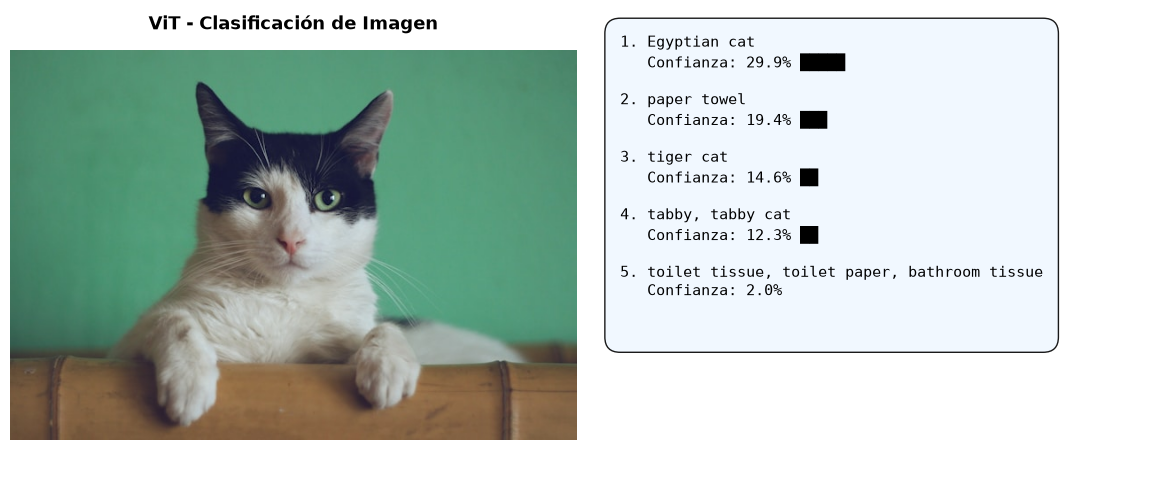

In [5]:
# Ejecutamos una inferencia de prueba con una imagen concreta para observar qué predice
# el ViT y con qué nivel de confianza, antes de aplicarlo a nuestras propias imágenes.
url_gato = 'https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=640'  # ?w=640 solicita la versión reducida para acelerar la descarga.
imagen_gato = cargar_imagen_url(url_gato)

if imagen_gato:  # Verificamos que la descarga fue exitosa antes de pasar la imagen al modelo.
    print('✦ Evaluando la imagen con ViT...')
    predicciones_vit = clasificador_vit(imagen_gato)  # El pipeline aplica internamente el preprocesado (resize, normalización, partición en parches).
    
    print('\nTop 5 Inferencias de ImageNet:')
    print('-' * 45)
    for i, res in enumerate(predicciones_vit[:5], 1):  # El pipeline devuelve las 1000 clases ordenadas; tomamos solo las 5 con mayor score.
        print(f'{i}. {res["label"]:25s} → Confianza: {res["score"]:.1%}')  # :25s alinea las etiquetas en columna para facilitar la lectura.
        
    mostrar_resultados(imagen_gato, predicciones_vit, 'ViT - Clasificación de Imagen')


In [6]:
# Ejercicio interactivo para que el estudiante pruebe el modelo con una imagen propia
# y compare las predicciones con las obtenidas en el ejemplo del gato.
print('✦ Ejercicio interactivo: Clasifiquen su propia muestra local con ViT')
print('=' * 65)

confirmacion = input('¿Quieren subir una imagen desde su entorno local? (s/n): ').lower()  # .lower() acepta 'S' o 's' indistintamente.

if confirmacion == 's':
    imagen_usuario = cargar_imagen_local()
    
    if imagen_usuario:  # cargar_imagen_local() retorna None si el archivo no se encontró.
        print('✦ Clasificando la muestra ingresada...')
        predicciones_usuario = clasificador_vit(imagen_usuario)
        
        print('\nResultados de la Inferencia:')
        print('-' * 45)
        for i, res in enumerate(predicciones_usuario[:5], 1):
            print(f'{i}. {res["label"]:25s} → {res["score"]:.1%}')
            
        mostrar_resultados(imagen_usuario, predicciones_usuario, 'ViT - Su Muestra')
else:
    print('✦ Excelente. Continuemos con el siguiente modelo multimodal.')


✦ Ejercicio interactivo: Clasifiquen su propia muestra local con ViT
✦ Excelente. Continuemos con el siguiente modelo multimodal.


### Preguntas para pensar:
* ¿Qué tan exactas resultaron ser las 5 categorías estimadas por ViT?



- De las cinco categorías, **tres identificaron correctamente que el sujeto era un gato**: *Egyptian cat* (29,9 %), *tiger cat* (14,6 %) y *tabby cat* (12,3 %). Sin embargo, las razas propuestas no coinciden claramente con el gato de la imagen, por lo que la clasificación fue correcta a nivel general, pero poco precisa en la subcategoría.

- Las predicciones *paper towel* (19,4 %) y *toilet tissue* (2 %) son incorrectas. Probablemente surgieron por la textura y el color blanco del pelaje, que presentan similitudes visuales con papel.

* ¿El modelo demostró captar rasgos sutiles del fondo de la imagen o se enfocó estrictamente en el sujeto central?
En conjunto, ViT se enfocó principalmente en el **sujeto central**, ya que tres resultados corresponden a gatos. No hay evidencias claras de que haya reconocido elementos sutiles del fondo verde o de la superficie de madera. Las categorías relacionadas con papel parecen una confusión con el pelaje blanco, no una interpretación real del fondo.

Además, la confianza máxima fue relativamente baja —29,9 %—, lo que indica que el modelo reconoció un gato, pero mostró bastante incertidumbre al determinar su clase exacta.

## ✦ MODELO 2: CLIP (Contrastive Language-Image Pre-training)

**CLIP** (diseñado por OpenAI) conecta de manera directa imágenes complejas con representaciones textuales de lenguaje natural. Esto les permite clasificar de forma libre mediante descripciones abstractas creadas en el momento, eludiendo las restricciones de categorías preestablecidas (Zero-Shot).

In [7]:
# Cargamos CLIP (Contrastive Language–Image Pretraining), un modelo multimodal de OpenAI
# entrenado para alinear imágenes y texto en un espacio de embeddings compartido.
# A diferencia del ViT anterior, CLIP puede clasificar en categorías arbitrarias definidas
# en tiempo de inferencia, sin necesidad de haber sido entrenado sobre ellas (zero-shot).
print('✦ Descargando pesos oficiales de OpenAI CLIP (clip-vit-base-patch32)...')
print('  (Este proceso puede tardar un momento)')

# 'zero-shot-image-classification': el pipeline recibe etiquetas de texto en cada llamada
# y compara el embedding de la imagen contra el embedding de cada etiqueta para rankearlas.
clasificador_clip = pipeline(
    'zero-shot-image-classification',
    model='openai/clip-vit-base-patch32'  # patch32: parches de 32×32 px (más grandes que el ViT anterior, más rápido pero menos detallado).
)

print('\n✓ Modelo CLIP multimodal cargado y listo para clasificar.')


✦ Descargando pesos oficiales de OpenAI CLIP (clip-vit-base-patch32)...
  (Este proceso puede tardar un momento)


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 24806.57it/s]



✓ Modelo CLIP multimodal cargado y listo para clasificar.


## 4.1. Pruebas Experimentales con CLIP (Zero-Shot)

Definiremos un conjunto de etiquetas personalizadas creadas en tiempo de ejecución para clasificar una imagen compleja.

✓ Imagen remota cargada con éxito.
  • Resolución original: (640, 427)
✦ Categorías personalizadas definidas para CLIP:
  • 1. auriculares de diadema en fondo calido
  • 2. dispositivo electronico antiguo
  • 3. computadora portatil encendida
  • 4. un telefono movil inteligente
  • 5. una persona escuchando música
  • 6. auriculares negros

✦ Procesando inferencia zero-shot...

Resultados de Confianza Calculados:
-----------------------------------------------------------------
1. auriculares negros                  → 74.4% ██████████████████████
2. auriculares de diadema en fondo calido → 13.5% ████
3. una persona escuchando música       → 10.7% ███
4. un telefono movil inteligente       → 0.5% 
5. dispositivo electronico antiguo     → 0.4% 
6. computadora portatil encendida      → 0.4% 


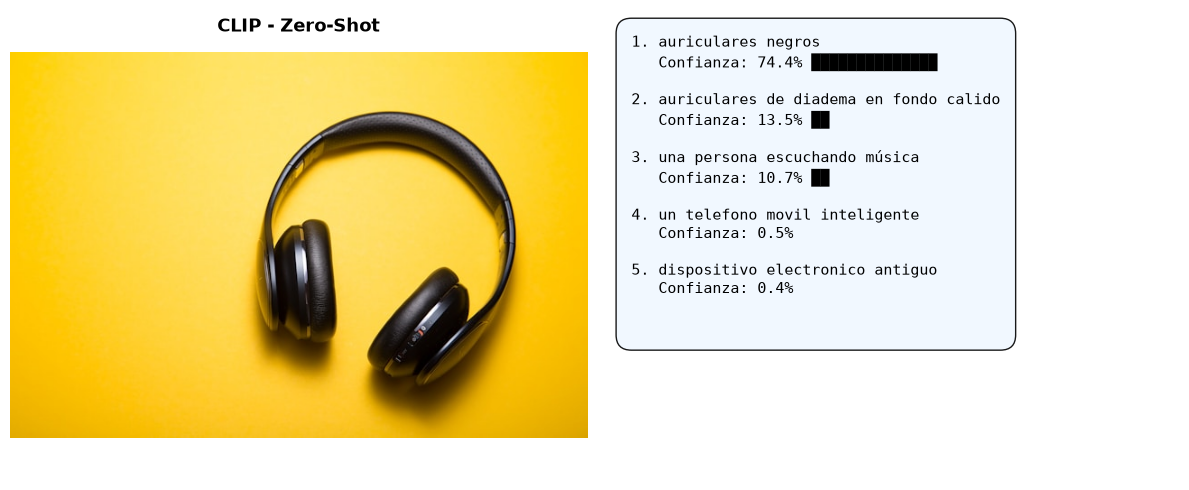

In [8]:
# Demostramos la capacidad zero-shot de CLIP: las etiquetas se definen libremente en lenguaje
# natural y se pasan en el momento de la inferencia, sin reentrenar ni ajustar el modelo.
url_auriculares = 'https://images.unsplash.com/photo-1505740420928-5e560c06d30e?w=640'
imagen_auriculares = cargar_imagen_url(url_auriculares)

if imagen_auriculares:
    # A diferencia de ImageNet, estas etiquetas pueden ser cualquier descripción en lenguaje
    # natural; CLIP las entiende porque fue entrenado con pares imagen-texto, no con clases fijas.
    etiquetas_candidatas = [
        'auriculares de diadema en fondo calido',
        'dispositivo electronico antiguo',
        'computadora portatil encendida',
        'un telefono movil inteligente',
        'una persona escuchando música',
        'auriculares negros'
    ]
    
    print('✦ Categorías personalizadas definidas para CLIP:')
    for i, cat in enumerate(etiquetas_candidatas, 1):
        print(f'  • {i}. {cat}')
        
    print('\n✦ Procesando inferencia zero-shot...')
    # candidate_labels es el parámetro que habilita el zero-shot: CLIP compara el embedding
    # de la imagen contra el embedding de cada etiqueta y retorna probabilidades relativas.
    resultados_clip = clasificador_clip(imagen_auriculares, candidate_labels=etiquetas_candidatas)
    
    print('\nResultados de Confianza Calculados:')
    print('-' * 65)
    for i, res in enumerate(resultados_clip, 1):
        barra_visual = '█' * int(res['score'] * 30)  # Escala a 30 chars (mayor que el ejemplo del ViT) para compensar las etiquetas más largas.
        print(f'{i}. {res["label"]:35s} → {res["score"]:.1%} {barra_visual}')
        
    mostrar_resultados(imagen_auriculares, resultados_clip, 'CLIP - Zero-Shot')


✦ Ejercicio interactivo: Definan sus propias categorías y evalúen con CLIP

✦ Seleccionen la fuente de la imagen:
✓ Imagen remota cargada con éxito.
  • Resolución original: (4160, 6240)
✦ Evaluando imagen zero-shot con CLIP...

Resultados de Inferencia:
-------------------------------------------------------
1. planta                    → 92.6% ███████████████████████
2. arbol                     → 3.3% 
3. cesped                    → 2.1% 
4. flor                      → 1.9% 
5. perro                     → 0.1% 
6. gato                      → 0.0% 
7. pez                       → 0.0% 


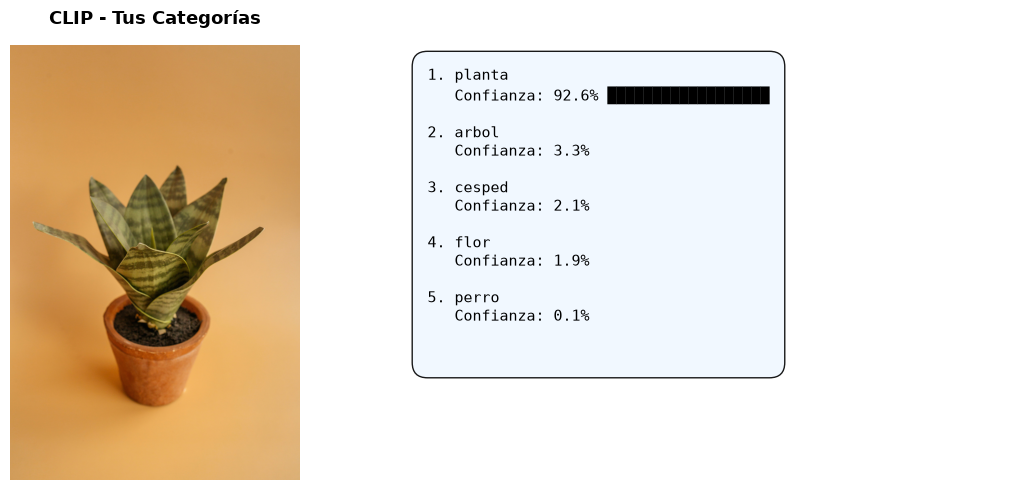

In [13]:
# Ejercicio interactivo para que el estudiante experimente el zero-shot de CLIP con
# categorías y una imagen propias, sin modificar el modelo ni el código de inferencia.
print('✦ Ejercicio interactivo: Definan sus propias categorías y evalúen con CLIP')
print('=' * 75)

confirmacion = input('¿Quieren evaluar con categorías personalizadas (s/n): ').lower()

if confirmacion == 's':
    linea_categorias = input('Ingresen 3 o 4 categorías separadas por comas (ej. paisaje nocturno, auto veloz, comida gourmet): ')
    lista_categorias = [#planta, arbol, cesped, flor, perro, gato, pez
        ]
    
    for cat in linea_categorias.split(','):
        if cat.strip():  # Descarta entradas vacías que pueden aparecer si el usuario puso coma al final o dos comas seguidas.
            lista_categorias.append(cat.strip())  # strip() elimina espacios al inicio y al final de cada categoría.
            
    if len(lista_categorias) >= 2:  # CLIP calcula probabilidades relativas entre candidatos; con menos de 2 no hay comparación posible.
        print('\n✦ Seleccionen la fuente de la imagen:')
        fuente = input('Ingrese l para archivo local o u para dirección URL: ').lower()
        
        imagen_personalizada = None  # Se inicializa en None para que el if final siempre tenga la variable definida, independientemente de la rama elegida.
        if fuente == 'l':
            imagen_personalizada = cargar_imagen_local()
        elif fuente == 'u':
            url_personalizada = input('Ingresen la dirección URL completa: ')#https://6a36da4005d679a122fa5962.imgix.net/plant.jpg
            imagen_personalizada = cargar_imagen_url(url_personalizada)
            
        if imagen_personalizada:
            print('✦ Evaluando imagen zero-shot con CLIP...')
            resultados_usuario = clasificador_clip(imagen_personalizada, candidate_labels=lista_categorias)
            
            print('\nResultados de Inferencia:')
            print('-' * 55)
            for i, res in enumerate(resultados_usuario, 1):
                barra = '█' * int(res['score'] * 25)
                print(f'{i}. {res["label"]:25s} → {res["score"]:.1%} {barra}')
                
            mostrar_resultados(imagen_personalizada, resultados_usuario, 'CLIP - Tus Categorías')
    else:
        print('✗ Error: Deben definir al menos 2 categorías para comparar.')
else:
    print('✦ Entendido. Avancemos con el detector de objetos DETR.')


### Preguntas para pensar:



* **¿Cómo se compara el potencial de búsqueda de CLIP frente a la clasificación fija de ViT?** CLIP ofrece una búsqueda mucho más flexible que la clasificación fija de ViT. Un clasificador ViT entrenado con ImageNet solo puede elegir entre sus categorías predefinidas. CLIP, en cambio, compara imágenes con descripciones escritas libremente, sin reentrenar el modelo.

Por ejemplo, CLIP podría buscar:

- “un gato blanco y negro sobre una superficie de madera”.
- “calzado deportivo utilizado al aire libre”.
- “una imagen con ambiente nocturno”.

Esto permite buscar por objetos, atributos, acciones y contexto. Sin embargo, sus resultados representan similitud semántica y pueden depender mucho de cómo se redacten las etiquetas.

* **¿En qué escenarios de la vida real preferirían utilizar CLIP por sobre un clasificador tradicional?**

Preferiría CLIP en escenarios como:

- Buscadores de imágenes mediante lenguaje natural.
- Organización y etiquetado flexible de grandes colecciones.
- Moderación o filtrado con categorías que cambian frecuentemente.
- Comercio electrónico, para buscar productos por descripción.
- Prototipos donde todavía no existen datos etiquetados.
- Detección rápida de conceptos nuevos sin reentrenamiento.

Un clasificador tradicional resulta más conveniente cuando las categorías son fijas, se dispone de suficientes ejemplos etiquetados y se necesita mayor precisión, control y consistencia para una tarea específica.

## ✦ MODELO 3: DETR (Detection Transformer)

**DETR (Detection Transformer)** (desarrollado por Facebook AI) trasciende la clasificación global para localizar y enmarcar de forma espacial múltiples objetos de forma de simultánea dentro de una escena, proporcionando coordenadas precisas (*bounding boxes*) usando la arquitectura Transformer.

In [14]:
# Cargamos DETR (DEtection TRansformer), que a diferencia de ViT y CLIP no clasifica
# la imagen completa, sino que localiza y clasifica múltiples objetos simultáneamente,
# devolviendo una caja delimitadora (bounding box) y una etiqueta por cada objeto detectado.
print('✦ Descargando pesos oficiales de Facebook DETR (detr-resnet-50)...')
print('  (Este proceso puede tardar un momento)')

# 'detr-resnet-50': usa ResNet-50 como extractor de características visuales (backbone)
# y un Transformer encoder-decoder para predecir objetos sin necesidad de anclas fijas.
detector_detr = pipeline(
    'object-detection',  # La salida incluye label, score y box (xmin, ymin, xmax, ymax) por cada objeto.
    model='facebook/detr-resnet-50'
)

print('\n✓ Modelo DETR cargado correctamente.')
print('  • Entrenado en el dataset COCO (91 categorías de objetos comunes).')


✦ Descargando pesos oficiales de Facebook DETR (detr-resnet-50)...
  (Este proceso puede tardar un momento)


Loading weights: 100%|██████████| 530/530 [00:00<00:00, 10459.51it/s]
[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✓ Modelo DETR cargado correctamente.
  • Entrenado en el dataset COCO (91 categorías de objetos comunes).


In [15]:
# Define la función que dibuja los bounding boxes y etiquetas sobre la imagen
# para visualizar los resultados de DETR. Opera sobre una copia para no alterar el original.
def dibujar_detecciones_en_imagen(imagen, detecciones, umbral=0.7):
    copia_imagen = imagen.copy()  # Trabajamos sobre una copia para preservar la imagen original sin anotaciones.
    dibujador = ImageDraw.Draw(copia_imagen)
    
    colores_disponibles = ['red', 'blue', 'green', 'magenta', 'purple', 'orange', 'cyan']
    conteo_validos = 0
    
    for det in detecciones:
        if det['score'] >= umbral:  # Descartamos detecciones con baja confianza para evitar falsos positivos en la visualización.
            caja = det['box']
            etiqueta = det['label']
            confianza = det['score']
            
            # Las coordenadas del modelo vienen como floats; PIL requiere enteros para dibujar.
            xmin = int(caja['xmin'])
            ymin = int(caja['ymin'])
            xmax = int(caja['xmax'])
            ymax = int(caja['ymax'])
            
            # El módulo cicla los colores si hay más objetos detectados que colores disponibles.
            color = colores_disponibles[conteo_validos % len(colores_disponibles)]
            
            dibujador.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)
            
            texto_descriptivo = f'{etiqueta} {confianza:.2%}'
            # Dibujamos un fondo de color sólido 15px por encima del borde superior del box;
            # el ancho se estima multiplicando la cantidad de caracteres por ~8px por carácter.
            dibujador.rectangle([xmin, ymin - 15, xmin + len(texto_descriptivo) * 8, ymin], fill=color)
            dibujador.text((xmin + 2, ymin - 13), texto_descriptivo, fill='white')  # +2, -13 centra el texto dentro del fondo coloreado.
            
            conteo_validos += 1
            
    return copia_imagen, conteo_validos  # Retorna la imagen anotada y la cantidad de objetos dibujados para que el llamador pueda informarlo.

print('✓ Función de graficación de bounding boxes compilada.')


✓ Función de graficación de bounding boxes compilada.


## 5.1. Pruebas Experimentales con DETR

Evaluaremos la capacidad de detección espacial de DETR en una escena compleja que agrupa múltiples objetos domésticos.

✓ Imagen remota cargada con éxito.
  • Resolución original: (640, 480)
✦ Detectando objetos con DETR...

✓ Se detectaron 1 elementos en total:
-----------------------------------------------------------------
 1. dog             → Confianza: 97.8%
     Posición: (285, 111) - (639, 480) | Tamaño: 354x369 px



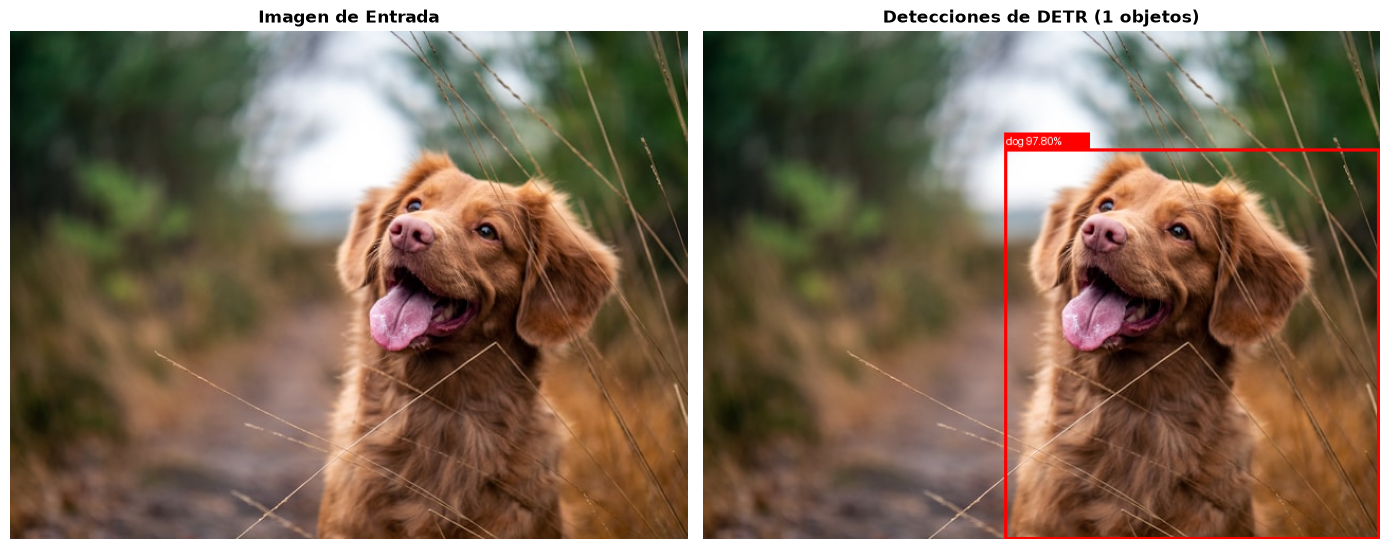

In [16]:
# Ejecutamos la detección con DETR y comparamos visualmente la imagen original
# contra la imagen anotada con bounding boxes para evaluar la calidad del modelo.
url_perros = 'https://images.unsplash.com/photo-1544568100-847a948585b9?w=640'
imagen_perros = cargar_imagen_url(url_perros)

if imagen_perros:
    print('✦ Detectando objetos con DETR...')
    detecciones = detector_detr(imagen_perros)  # Retorna TODAS las detecciones del modelo, incluyendo las de baja confianza.
    
    # Imprimimos todas las detecciones para ver también las de baja confianza,
    # antes de aplicar el filtro de umbral en la visualización.
    print(f'\n✓ Se detectaron {len(detecciones)} elementos en total:')
    print('-' * 65)
    for i, det in enumerate(detecciones, 1):
        caja = det['box']
        ancho_px = int(caja['xmax'] - caja['xmin'])  # Calculamos el tamaño del box para entender qué proporción de la imagen ocupa cada objeto.
        alto_px  = int(caja['ymax'] - caja['ymin'])
        print(f'{i:2d}. {det["label"]:15s} → Confianza: {det["score"]:.1%}')
        print(f'     Posición: ({int(caja["xmin"])}, {int(caja["ymin"])}) - ({int(caja["xmax"])}, {int(caja["ymax"])}) | Tamaño: {ancho_px}x{alto_px} px\n')
        
    # umbral=0.7 filtra las detecciones para la visualización; puede haber menos boxes que detecciones totales.
    imagen_analizada, validos = dibujar_detecciones_en_imagen(imagen_perros, detecciones, umbral=0.7)
    
    # Mostramos original y anotada lado a lado para que el contraste evidencie qué detectó el modelo.
    plt.figure(figsize=(14, 7))
    
    plt.subplot(1, 2, 1)
    plt.imshow(imagen_perros)
    plt.title('Imagen de Entrada', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(imagen_analizada)
    plt.title(f'Detecciones de DETR ({validos} objetos)', fontsize=12, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


✦ Ejercicio interactivo: Detecten objetos en su propia imagen
✦ Seleccionen la fuente de la imagen:
✓ Imagen remota cargada con éxito.
  • Resolución original: (3840, 2160)
✦ Ejecutando detección con DETR...

✓ Se detectaron 1 elementos:
  • 1. bird (100.0%)


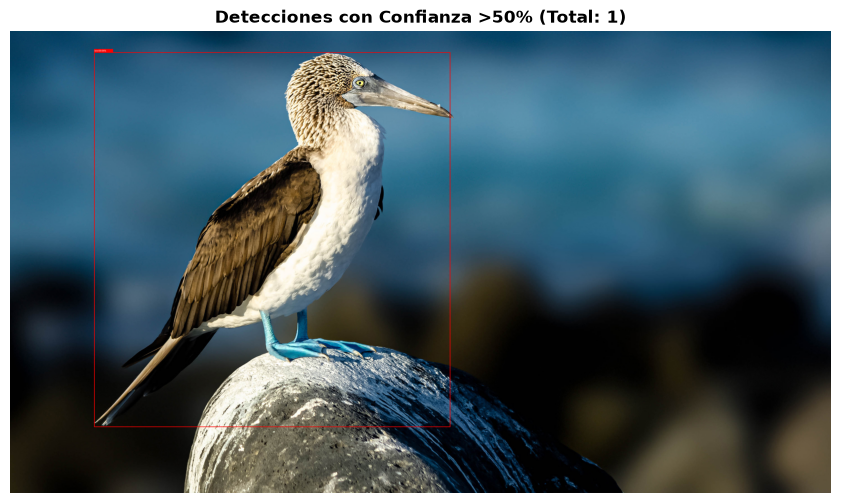

In [19]:
# Ejercicio interactivo para que el estudiante pruebe DETR con su propia imagen
# y observe qué objetos detecta el modelo y con qué nivel de confianza.
print('✦ Ejercicio interactivo: Detecten objetos en su propia imagen')
print('=' * 65)

confirmacion = input('¿Quieren subir una imagen para detectar objetos (s/n): ').lower()

if confirmacion == 's':
    print('✦ Seleccionen la fuente de la imagen:')
    fuente = input('Ingrese l para archivo local o u para dirección URL: ').lower()
    
    imagen_usuario = None  # Se inicializa en None antes del if/elif para que siempre esté definida al llegar al if siguiente.
    if fuente == 'l':
        imagen_usuario = cargar_imagen_local()
    elif fuente == 'u':
        url_usuario = input('Ingresen la dirección URL completa: ')
        imagen_usuario = cargar_imagen_url(url_usuario)
        
    if imagen_usuario:
        print('✦ Ejecutando detección con DETR...')
        mis_detecciones = detector_detr(imagen_usuario)
        
        if mis_detecciones:  # El modelo puede no detectar nada si la imagen no contiene objetos de las 91 clases COCO.
            print(f'\n✓ Se detectaron {len(mis_detecciones)} elementos:')
            for i, det in enumerate(mis_detecciones, 1):
                print(f'  • {i}. {det["label"]} ({det["score"]:.1%})')
                
            # Umbral 0.5 (más permisivo que el 0.7 del ejemplo anterior) para aumentar
            # la probabilidad de ver detecciones en imágenes de contenido desconocido.
            imagen_con_cajas, total_dibujados = dibujar_detecciones_en_imagen(imagen_usuario, mis_detecciones, umbral=0.5)
            
            plt.figure(figsize=(12, 6))
            plt.imshow(imagen_con_cajas)
            plt.title(f'Detecciones con Confianza >50% (Total: {total_dibujados})', fontsize=12, fontweight='bold')
            plt.axis('off')
            plt.show()
        else:
            print('✦ No se detectaron objetos con el umbral por defecto.')
else:
    print('✦ Perfecto. Avancemos al resumen comparativo final.')


### Preguntas para pensar:
* **¿Qué ventajas tiene conocer la ubicación exacta y el tamaño de los elementos en lugar de clasificar la imagen completa?**
Conocer la ubicación y el tamaño de cada elemento mediante **detección de objetos** aporta más información que clasificar la imagen completa. Además de indicar **qué objetos hay**, permite saber **cuántos son, dónde están y qué espacio ocupan**, incluso cuando aparecen varias clases simultáneamente.

Esto permite realizar seguimiento, mediciones, conteos y análisis de relaciones espaciales. Por ejemplo, no solo detectar que una imagen contiene personas, sino localizar a cada una y estimar si están demasiado cerca de una zona peligrosa.

* **¿Qué tipo de aplicaciones prácticas e industriales de Procesamiento de Imágenes se benefician directamente de este enfoque?**
Este enfoque beneficia aplicaciones como:

- Control de calidad industrial y localización de productos defectuosos.
- Robótica, manipulación de piezas y navegación autónoma.
- Vehículos autónomos y sistemas de asistencia al conductor.
- Videovigilancia, control de accesos y seguimiento de personas.
- Medicina, para localizar lesiones, tumores o anomalías.
- Agricultura de precisión, detectando frutos, plagas o malezas.
- Logística e inventarios, contando y ubicando productos.
- Comercio minorista, analizando estanterías y disponibilidad.
- Seguridad laboral, verificando cascos y otros equipos de protección.

En síntesis, la clasificación describe globalmente la imagen, mientras que la detección de objetos permite actuar sobre elementos concretos dentro de ella.

## 3. Comparación Técnica e Integración de los Modelos

Analizaremos los tres enfoques de visión artificial de última generación de forma comparativa:

### Tabla de Criterios

| Característica | Vision Transformer (ViT) | CLIP (OpenAI) | DETR (Facebook) |
| :--- | :--- | :--- | :--- |
| **Tarea Principal** | Clasificación de imagen completa | Clasificación libre Zero-Shot | Detección de múltiples objetos |
| **Categorías** | 1000 etiquetas fijas (ImageNet) | Infinitas (lenguaje natural) | 91 etiquetas fijas (COCO) |
| **Ubicación Espacial**| No (solo etiqueta global) | No (solo etiqueta global) | Sí (coordenadas de cajas) |
| **Velocidad de Inferencia** | Alta | Alta | Moderada |
| **Flexibilidad Didáctica** | Baja (rígida) | Extrema (flexible) | Media (acotada) |

In [20]:
# Resumen de criterios de selección entre los tres modelos explorados en el notebook.
print('✦ SÍNTESIS DE ESCENARIOS DE APLICACIÓN REAL:')
print('-' * 55)
print('  • Usen ViT:   Para indexación general y veloz de archivos masivos.')
print('  • Usen CLIP:  Para búsquedas semánticas personalizadas sin entrenamiento.')
print('  • Usen DETR:  Para robótica, automóviles autónomos e inventario espacial.')


✦ SÍNTESIS DE ESCENARIOS DE APLICACIÓN REAL:
-------------------------------------------------------
  • Usen ViT:   Para indexación general y veloz de archivos masivos.
  • Usen CLIP:  Para búsquedas semánticas personalizadas sin entrenamiento.
  • Usen DETR:  Para robótica, automóviles autónomos e inventario espacial.


## 4. Desafíos y Prácticas Prácticas Sugeridas

### Nivel Básico
1. **Comparación Cruzada:** Seleccionen la misma imagen y compárenla a través de los tres modelos para evaluar consistencia semántica.
2. **Ajuste Fino de CLIP:** Diseñen categorías en español altamente específicas (ej. un perrito descansando plácidamente, un perrito alerta vigilando) para evaluar la sutileza de CLIP.

### Nivel Intermedio
3. **Detector de Elementos de Protección Personal (EPP):** Utilicen CLIP para evaluar si una persona en una imagen posee casco y chaleco reflectante configurando esas clases de consulta.
4. **Conteo de Elementos de Inventario:** Utilicen DETR para contar la cantidad de elementos de una misma categoría (ej. cuántas tazas hay en la mesa) basándose en las detecciones.

### Nivel Avanzado (Desafío de Arquitectura)
5. **Sistema de Detección e Inferencia Híbrido:** Combinen DETR y CLIP de forma secuencial:
   - Utilicen DETR para detectar y recortar (crop) espacialmente todas las personas en una imagen.
   - Para cada persona recortada de forma individual, apliquen CLIP para clasificar de manera precisa si tiene barbijo o no.

## Cierre del Laboratorio

En este laboratorio aprendieron a desplegar modelos preentrenados de última generación de forma ágil mediante el ecosistema oficial de Hugging Face. Analizaron las capacidades y trade-offs entre clasificadores globales rígidos (ViT), clasificadores semánticos flexibles (CLIP) y detectores con localización espacial (DETR).

¡Sigan experimentando y diseñando sistemas innovadores de Procesamiento de Imágenes!